In [1]:
import palantir
import PINN
import os, sys
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

In [2]:
import matplotlib.pyplot as plt

In [3]:
os.chdir("../../")

# read the adata

In [4]:
meahr =  sc.read_h5ad("data/David_cellstates.h5ad")
meahr

AnnData object with n_obs × n_vars = 10250 × 7006
    obs: 'barcodes', 'batch_x', 'pseudodynamics_branching_region', 'pseudodynamics_branch_class', 'dpt_adjusted_groups', 'time', 'batch_y', 'pseudotime', 'cell', 'dc1', 'dc2', 'dc3', 'dc4', 'batch_to_match', 'leiden', 'Time_x', 'Time_y', 'dpt_pseudotime', 'dpt_groups', 'dpt_order', 'dpt_order_indices', 'palantir_pseudotime', 'palantir_entropy'
    var: 'TC_MAGIC_pdt_r', 'NK_MAGIC_pdt_r'
    uns: 'DM_EigenValues', 'Time_x_colors', 'Time_y_colors', 'diffmap_evals', 'dpt_changepoints', 'dpt_grouptips', 'iroot', 'leiden', 'leiden_colors', 'leiden_sizes', 'log1p', 'neighbors', 'paga', 'palantir_waypoints', 'pca', 'pop', 'pseudodynamics_branch_class_colors', 'umap'
    obsm: 'Cbl_Lpxn_scaled', 'Cbl_Rps6ka3_scaled', 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'X_Cbl_Adam19', 'X_Cbl_Lpxn', 'X_Cbl_Mllt3', 'X_Cbl_Rps6ka3', 'X_dc', 'X_diffmap', 'X_pca', 'X_tsne', 'X_umap', 'branch_masks', 'diff component', 'fated_pdt', 'palantir_fate_probabi

In [6]:
meahr.obs['pseudotime'].min(), meahr.obs['pseudotime'].max()

(0.0, 0.547317326068878)

In [12]:
pseudotime_scaled = meahr.obs['pseudotime'].values / meahr.obs['pseudotime'].max()
meahr.obsm['pseudotime_scaled'] = pseudotime_scaled.reshape(-1,1)

In [13]:
meahr.write_h5ad("data/David_cellstates.h5ad")

In [5]:
meahr.uns['pop']

{'mean': array([   16700,    28200,    86400,   236000,   979000,  2245000,
         5350000, 15630000]),
 'n_lib': array([5, 5, 5, 5, 5, 5, 2, 2]),
 't': array([12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5]),
 'var': array([  6700,  13400,  29900,  92600, 260000, 472000, 777818, 890955])}

In [6]:
meahr.obs.time.unique()

array([17.5, 18.5, 15.5, 13.5, 16.5, 14.5, 19.5, 12.5])

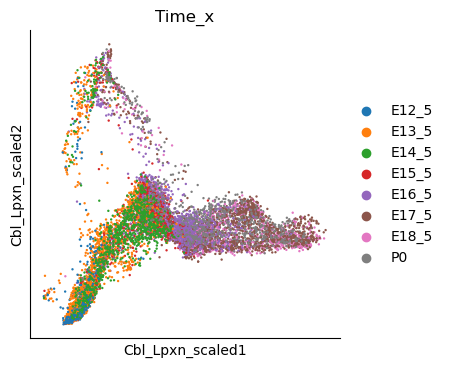

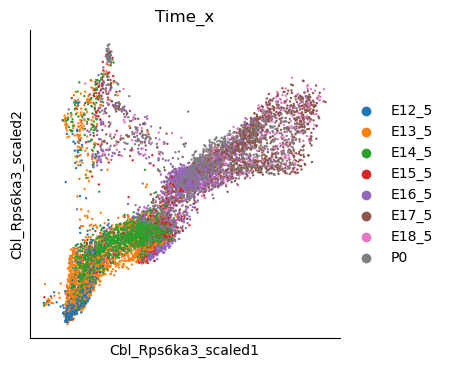

In [26]:
sc.pl.embedding(meahr, basis='Cbl_Lpxn_scaled',  color=['Time_x'])
sc.pl.embedding(meahr, basis='Cbl_Rps6ka3_scaled', color=['Time_x'])

In [8]:
from PINN import reader

In [9]:
def plot_meshgrid(cellstate_key):
    Dataset = reader.MeshGrid_AnnDS(
        AnnData = meahr,
        cellstate_key = cellstate_key,
        timepoint_key = 'time',
        n_grid = 50,
        log_transform = False,
        resampling_indensity = 0.3,
        resampling_rate = 0.3,
        norm_time = False,
        nearby_cellstate = 3,
    )

    u_b = Dataset.u_b
    PINN.pl.meshgrid_density_by_time(u_b,u_b, Dataset, cellstate_1='T-cell',cellstate_2='NK-cel');

In [10]:
Dataset = Dataset = reader.MeshGrid_AnnDS(
        AnnData = meahr,
        cellstate_key = "Cbl_Lpxn_scaled",
        timepoint_key = 'time',
        n_grid = 50,
        log_transform = False,
        resampling_indensity = 0.3,
        resampling_rate = 0.3,
        norm_time = False,
        nearby_cellstate = 3,
    )

XX = Dataset.s[:,0].reshape(50, 50)    # in DS, meshgrid is flatten
YY = Dataset.s[:,1].reshape(50, 50)
u_b = Dataset.u_b

In [11]:
meahr.obsm['fated_pdt'].min(axis=0), meahr.obsm['fated_pdt'].max(axis=0)

(array([0., 0.]), array([0.43090035, 0.52208199]))

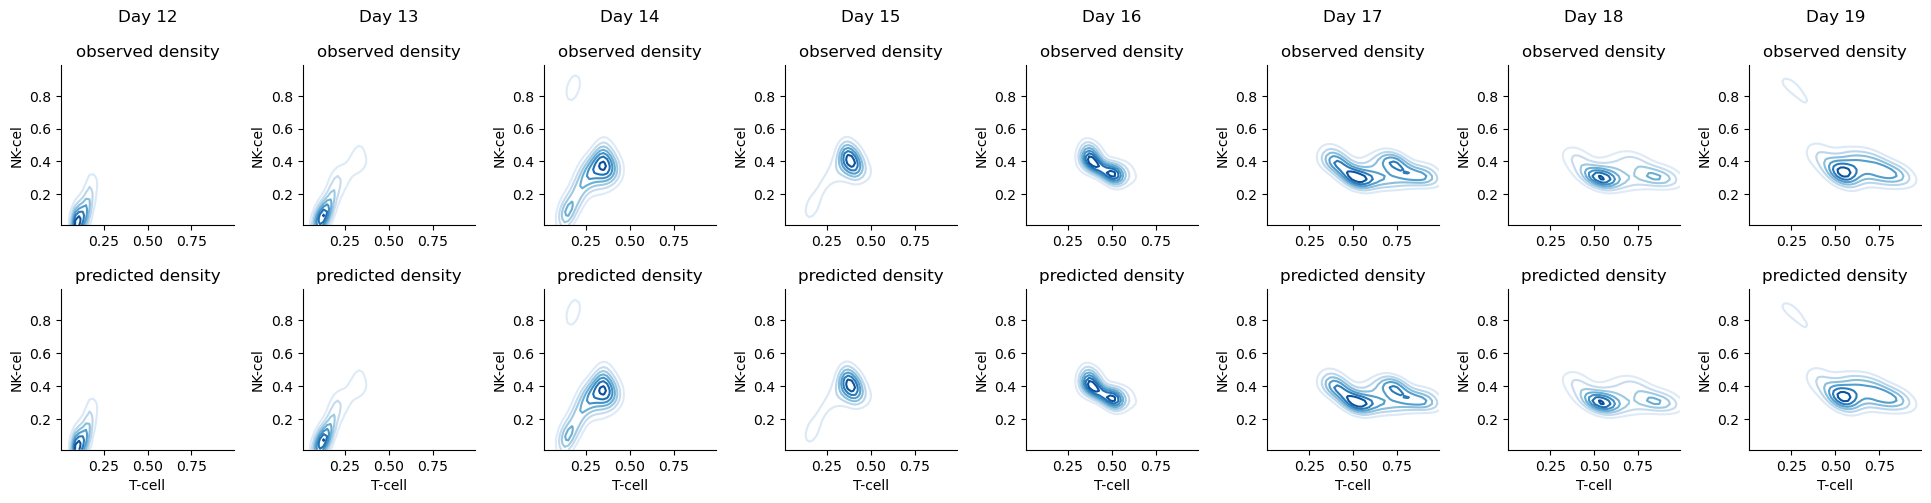

In [12]:
plot_meshgrid("Cbl_Lpxn_scaled")

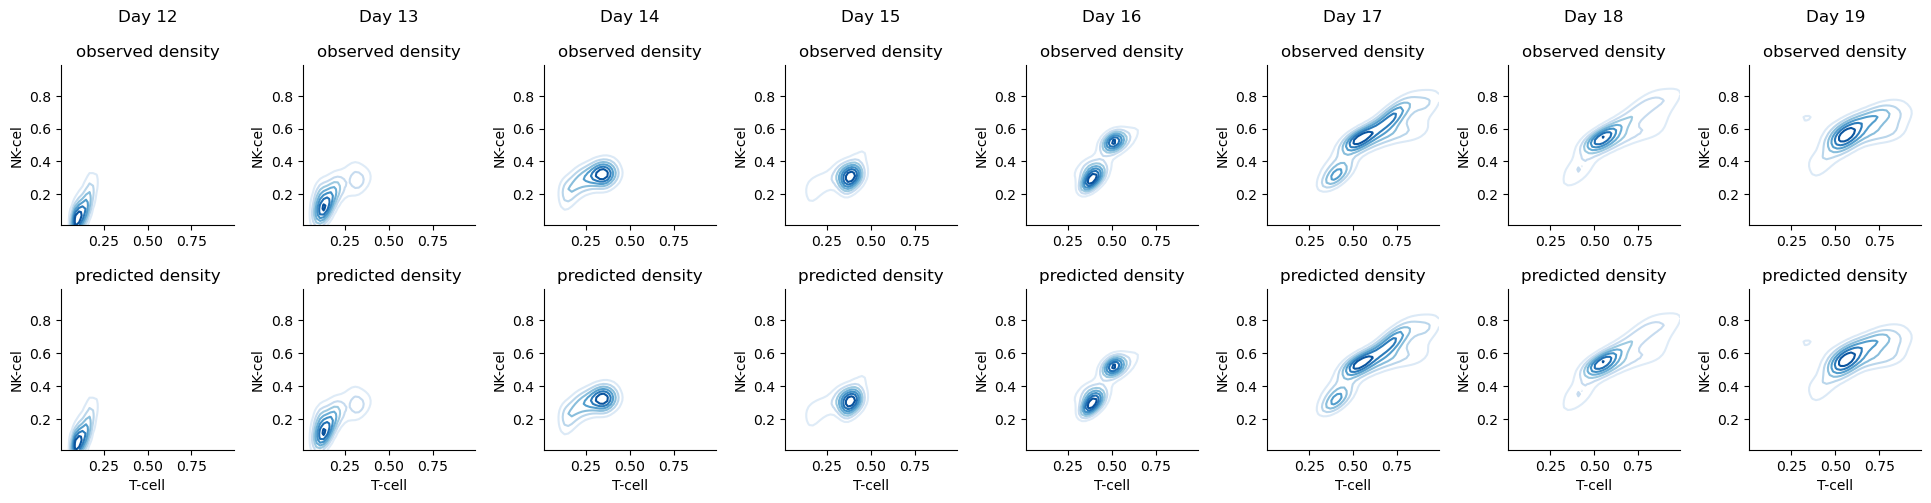

In [13]:
plot_meshgrid("Cbl_Rps6ka3_scaled")

array([12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5])

In [18]:
meahr.obsm['Cbl_Lpxn_scaled']

array([[0.70385054, 0.34750276],
       [0.36753785, 0.40585547],
       [0.69259776, 0.37270634],
       ...,
       [0.85404167, 0.3336816 ],
       [0.23689423, 0.84567112],
       [0.61759081, 0.32535033]])

/tmp/ipykernel_441861/2490828505.py:13: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(x=cellstate[:,0], y=cellstate[:,1], ax=axs[i], bw_adjust=1.2, label=label)


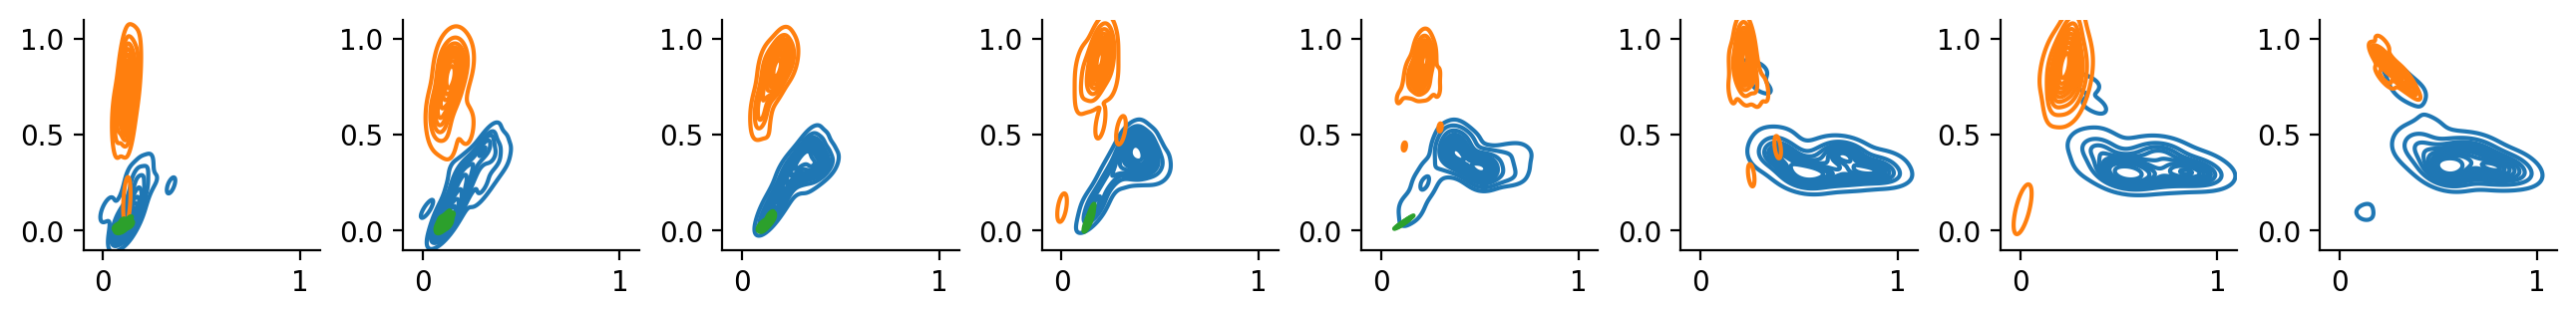

In [45]:
n_rows = len(Dataset.popD['t'])
fig, axs = plt.subplots(1,n_rows, figsize=(2*n_rows, 1.5), dpi=200, gridspec_kw={'wspace':0.35})
axs = axs.flatten()

for i,t in enumerate(Dataset.popD['t']):

    for label in ['TC', 'NK', 'progenitor']:

        cbs = meahr.obs.query("`time` == @t & `pseudodynamics_branch_class` == @label").index
        ad_t = meahr[cbs]
        cellstate = ad_t.obsm['Cbl_Lpxn_scaled']
        # 
        sns.kdeplot(x=cellstate[:,0], y=cellstate[:,1], ax=axs[i], bw_adjust=1.2, label=label)
        axs[i].set_xlim(-0.1,1.1)
        axs[i].set_ylim(-0.1,1.1)


In [56]:
np.where(meahr.obs.pseudodynamics_branch_class == 'NK')

(array([   28,    64,   150,   184,   194,   200,   254,   285,   322,
          402,   458,   507,   554,   570,   572,   593,   598,   609,
          620,   670,   679,   681,   686,   709,   733,   759,   762,
          783,   846,   872,   917,   962,   969,   980,  1009,  1017,
         1020,  1032,  1033,  1041,  1075,  1103,  1128,  1132,  1138,
         1163,  1169,  1187,  1223,  1259,  1281,  1288,  1322,  1383,
         1420,  1426,  1456,  1465,  1473,  1478,  1495,  1509,  1514,
         1535,  1577,  1578,  1603,  1610,  1641,  1642,  1670,  1692,
         1713,  1723,  1788,  1790,  1800,  1833,  1850,  1855,  1881,
         1904,  1912,  1916,  1953,  1999,  2072,  2085,  2154,  2196,
         2316,  2319,  2356,  2361,  2379,  2383,  2385,  2386,  2423,
         2425,  2467,  2468,  2489,  2498,  2509,  2518,  2569,  2570,
         2576,  2584,  2589,  2606,  2614,  2620,  2632,  2712,  2822,
         2827,  2856,  2860,  2876,  2917,  2924,  2936,  2962,  2979,
      

In [57]:
cell_idxs = [2303,2302,1484,323, 2997,  3003,  3082,  3093,  3164,  3181,  3188,
         3205,  3212,  3254,  3311]

In [55]:
meahr.obs['pseudodynamics_branch_class'].cat.categories

Index(['NK', 'TC', 'progenitor'], dtype='object')

In [121]:
# assign grid with branch label
space = Dataset.s.numpy()
cellstate = meahr.obsm['Cbl_Lpxn_scaled']
h = 1/50
branch_align = []
for s in space:
    x, y = s
    
    cell_idxs = np.where(np.logical_and(
        np.logical_and( cellstate[:,0] > x, cellstate[:,0] < x+h),
        np.logical_and( cellstate[:,1] > y, cellstate[:,1] < y+h)
        )
    )[0].tolist()

    if len(cell_idxs) == 0:
        celltype = 'empty'
    else:
        celltype_count = meahr.obs.iloc[cell_idxs]['pseudodynamics_branch_class']
        celltype = celltype_count.value_counts().index[0]

    branch_align.append(celltype)


In [122]:
branch_align = np.array(branch_align).reshape(50,50)

for i in range(1,49):
    for j in range(1, 49):
        if branch_align[i,j] == 'empty':
            neighbors, counts = np.unique(branch_align[i-1:i+2:,j-1:j+2], return_counts=True)
            print(neighbors, counts)
            
            if 'NK' in neighbors:
                most_cell = 'NK'

            elif len(neighbors) >= 2:
                counts = np.where(neighbors=='empty',0,counts)
                most_cell = neighbors[np.argmax(counts)]
        
            branch_align[i,j] = most_cell

branch_align = branch_align.flatten()


['TC' 'empty' 'progenitor'] [1 7 1]
['TC' 'empty' 'progenitor'] [4 3 2]
['TC' 'empty'] [2 7]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [1 8]
['TC' 'empty'] [5 4]
['TC' 'empty'] [6 3]
['TC' 'empty'] [5 4]
['TC

(2500,)
(2500,)
(2500,)


/tmp/ipykernel_441861/3660262935.py:11: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(XX, YY, u_temp, cmap='Blues', vmin=np.quantile(u_temp, 0.8), label=cell)


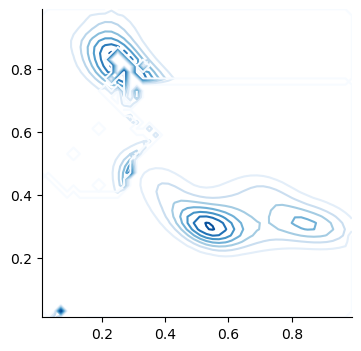

In [123]:
u_t = u_b[6]
for cell in np.unique(branch_align):
    if cell == 'empty':
        continue

    u_temp = np.where(np.array(branch_align) == cell,
                   u_t,0)
    print(u_temp.shape)
    
    u_temp = u_temp.reshape(50,50)
    plt.contour(XX, YY, u_temp, cmap='Blues', vmin=np.quantile(u_temp, 0.8), label=cell)

In [79]:
np.quantile(np.log(u_b[6]), [0,0.1, 0.2,0.5,0.8,0.9])

array([-69.07755279, -29.73867787, -15.50263717,  -5.23096512,
        -2.32742605,  -0.75403204])

 "linear", "log", "symlog", "logit",

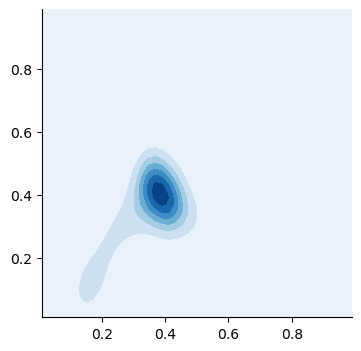

In [95]:
plt.contourf(XX, YY, u_b[3].reshape(50,50), norm="linear",
             cmap='Blues')

<Axes: xlabel='pseudotime', ylabel='Density'>

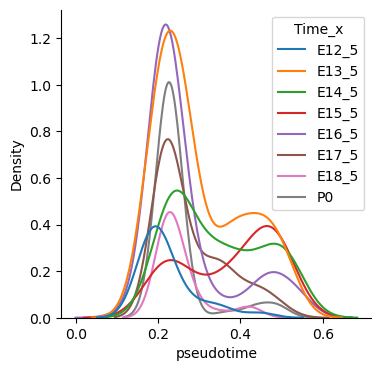

In [103]:
sns.kdeplot(
    data=meahr.obs.query("`pseudodynamics_branch_class`=='NK'"),
    x = 'pseudotime',
    hue='Time_x'
)


<Axes: xlabel='pseudotime', ylabel='Density'>

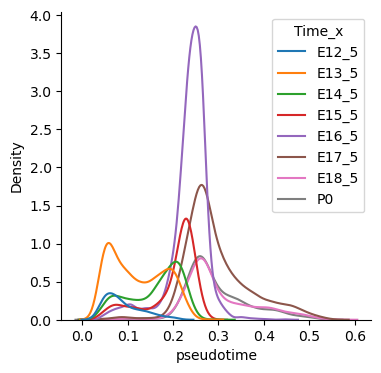

In [104]:
sns.kdeplot(
    data=meahr.obs.query("`pseudodynamics_branch_class`=='TC'"),
    x = 'pseudotime',
    hue='Time_x'
)


<Axes: xlabel='pseudotime_scaled', ylabel='Density'>

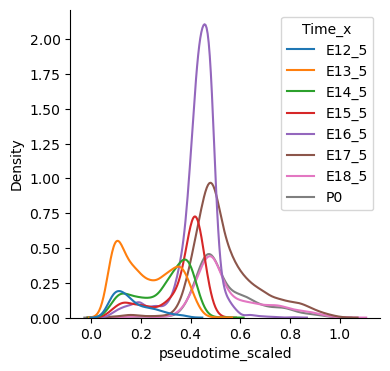

In [8]:
sns.kdeplot(
    data=meahr.obs.query("`pseudodynamics_branch_class`=='TC'"),
    x = 'pseudotime_scaled',
    hue='Time_x'
)


<Axes: xlabel='pseudotime', ylabel='Density'>

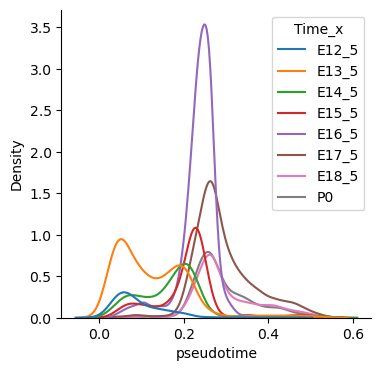

In [105]:
sns.kdeplot(
    data=meahr.obs,
    x = 'pseudotime',
    hue='Time_x'
)


In [127]:
input = pd.read_csv("/ssd/users/Wergillius/Project/PINN_dynamics/data/meahr/pdny_input/pseudodynamics_input_maehr17_dpt_branching_TCandNK.csv")
input['cell'] = input['cell'].apply(lambda x: x.replace(".e", ".E").replace('5whole', '5_Whole'))
input['cell']  = input['cell'].apply(lambda x : x.replace("P0_RightLobe", "P0_WholeThy_rep2"))
input['cell']  = input['cell'].apply(lambda x : x.replace("P0_LeftLobe", "P0_WholeThy_rep1"))

input['batch'] = input['batch'].apply(lambda x: x.replace("e1", "E1").replace('5whole', '5_Whole'))
input['barcodes'] = input['cell'].apply(lambda x: x.split(".")[0])
input['batch_to_match'] = input['cell'].apply(lambda x: x.split(".")[1])
input['time'] = input['time'].astype(str)

<Axes: xlabel='pseudotime', ylabel='Density'>

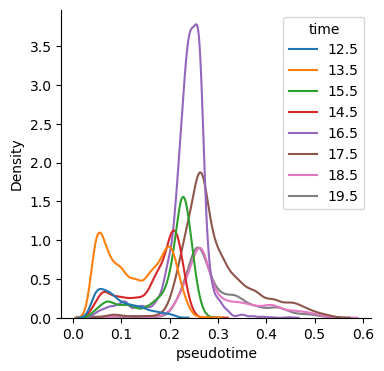

In [129]:
sns.kdeplot(
    data=input.query("`pseudodynamics_branch_class`=='TC'"),
    x = 'pseudotime',
    hue='time',
    bw_adjust=0.7
)


<Axes: xlabel='pseudotime', ylabel='Density'>

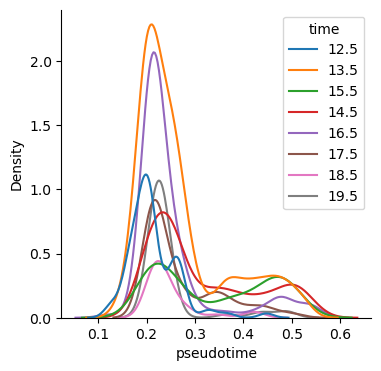

In [130]:
sns.kdeplot(
    data=input.query("`pseudodynamics_branch_class`=='NK'"),
    x = 'pseudotime',
    hue='time',
    bw_adjust=0.7
)
